# Wine Quality — Exploratory Data Analysis (EDA)

This notebook performs a comprehensive EDA on the Wine Quality dataset. It follows the assignment requirements: data loading, cleaning, univariate and bivariate analysis, correlation analysis, and a final summary of key insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Configure plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Libraries imported successfully!")

Libraries imported successfully!


## Data Loading
Read the provided CSV file and preview the data. The CSV `WineQT.csv` is expected to be in the notebook working directory (workspace root).

In [2]:
# Load dataset
df = pd.read_csv('WineQT.csv')
# Quick preview
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
# Shape and info
print('Shape:', df.shape)
df.info()

Shape: (1143, 13)
<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


## Data Cleaning
Check for missing values, duplicates, and ensure appropriate dtypes. Convert or rename columns if needed.

In [4]:
# Missing values and duplicates
print('Missing values per column:\n', df.isnull().sum())
print('\nTotal duplicates:', df.duplicated().sum())
# Show dtypes
df.dtypes

Missing values per column:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Total duplicates: 0


fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object

In [5]:
# If quality is numeric integer, consider treating it as categorical for some plots
if pd.api.types.is_integer_dtype(df['quality']):
    df['quality_cat'] = df['quality'].astype('category')
else:
    df['quality_cat'] = df['quality']
# Confirm change
df['quality_cat'].head()

0    5
1    5
2    5
3    6
4    5
Name: quality_cat, dtype: category
Categories (6, int64): [3, 4, 5, 6, 7, 8]

## Univariate Analysis
Explore distributions for key variables: `quality`, `alcohol`, `residual sugar`, `pH`, and `volatile acidity`.

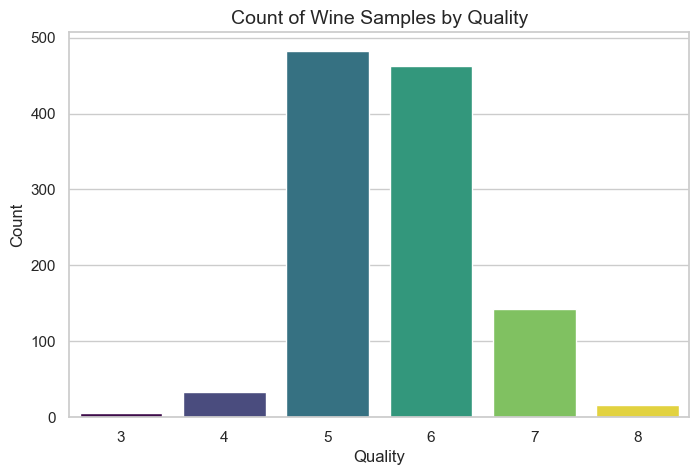

In [13]:
# Distribution of the target variable: quality
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='quality', hue='quality', palette='viridis', legend=False)
plt.title('Count of Wine Samples by Quality')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

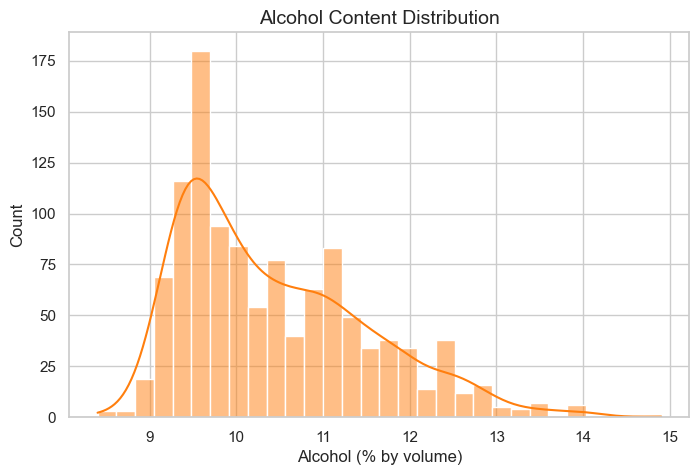

In [7]:
# Alcohol distribution
plt.figure(figsize=(8,5))
sns.histplot(df['alcohol'].dropna(), kde=True, bins=30, color='tab:orange')
plt.title('Alcohol Content Distribution')
plt.xlabel('Alcohol (% by volume)')
plt.show()

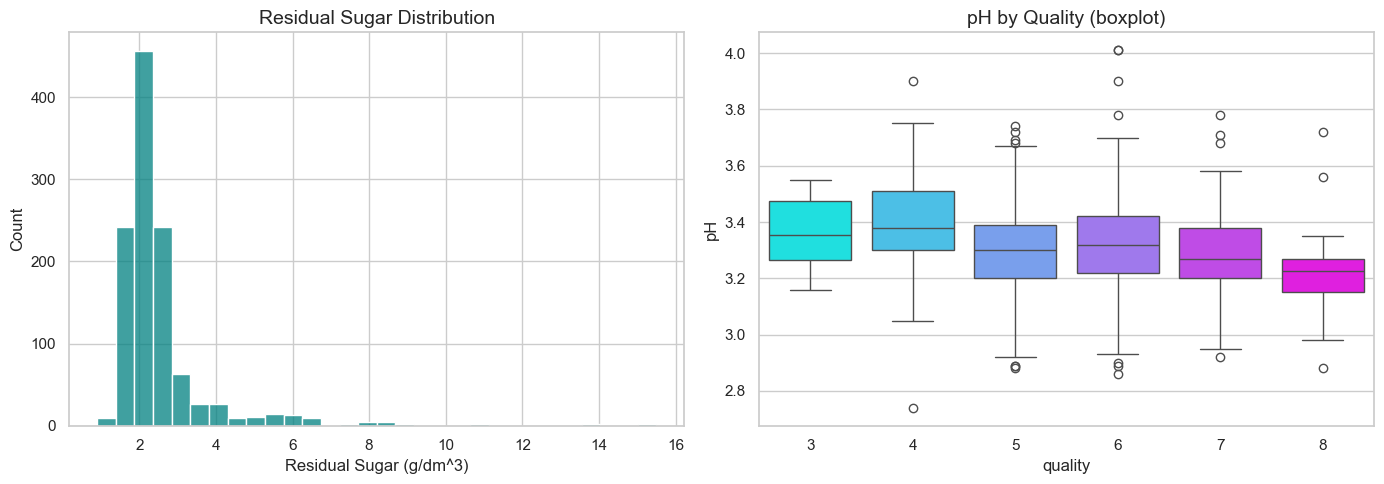

In [14]:
# Residual sugar and pH boxplots
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df['residual sugar'].dropna(), bins=30, ax=axes[0], color='teal')
axes[0].set_title('Residual Sugar Distribution')
axes[0].set_xlabel('Residual Sugar (g/dm^3)')
sns.boxplot(data=df, x='quality', y='pH', hue='quality', ax=axes[1], palette='cool', legend=False)
axes[1].set_title('pH by Quality (boxplot)')
plt.tight_layout()
plt.show()

## Bivariate Analysis
Investigate relationships between chemical properties and quality. We'll use scatter plots, boxplots grouped by quality, and correlation checks.

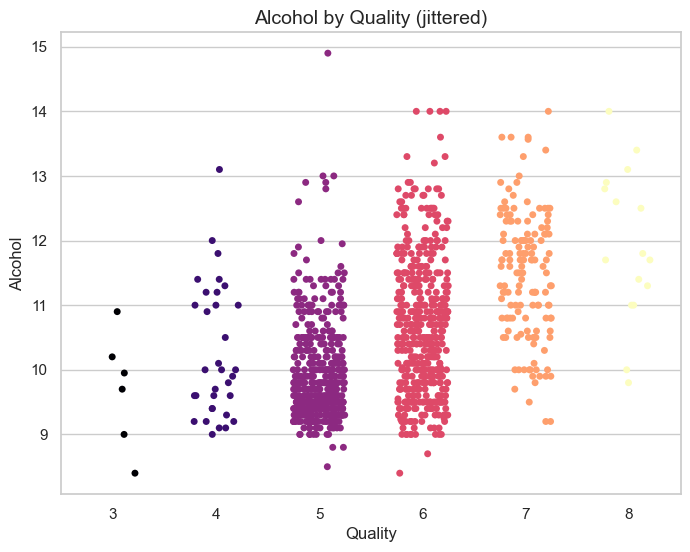

In [15]:
# Alcohol vs Quality (scatter + jitter using stripplot for clarity)
plt.figure(figsize=(8,6))
sns.stripplot(data=df, x='quality', y='alcohol', hue='quality', jitter=0.25, palette='magma', legend=False)
plt.title('Alcohol by Quality (jittered)')
plt.xlabel('Quality')
plt.ylabel('Alcohol')
plt.show()

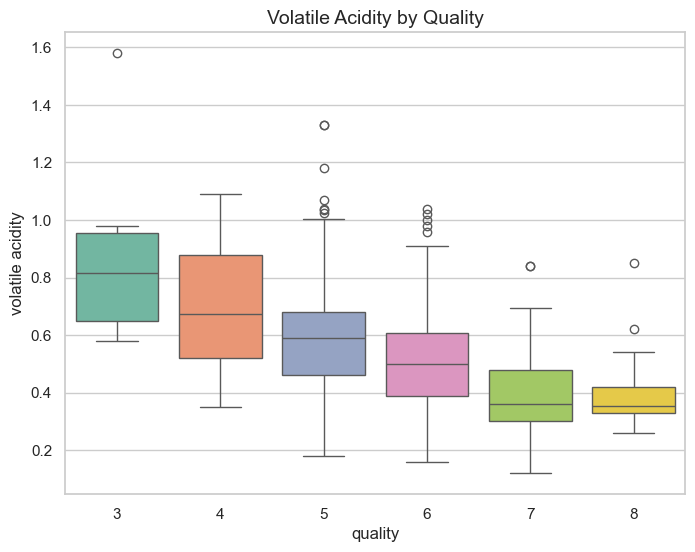

In [16]:
# Volatile acidity vs Quality (boxplot)
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='quality', y='volatile acidity', hue='quality', palette='Set2', legend=False)
plt.title('Volatile Acidity by Quality')
plt.show()

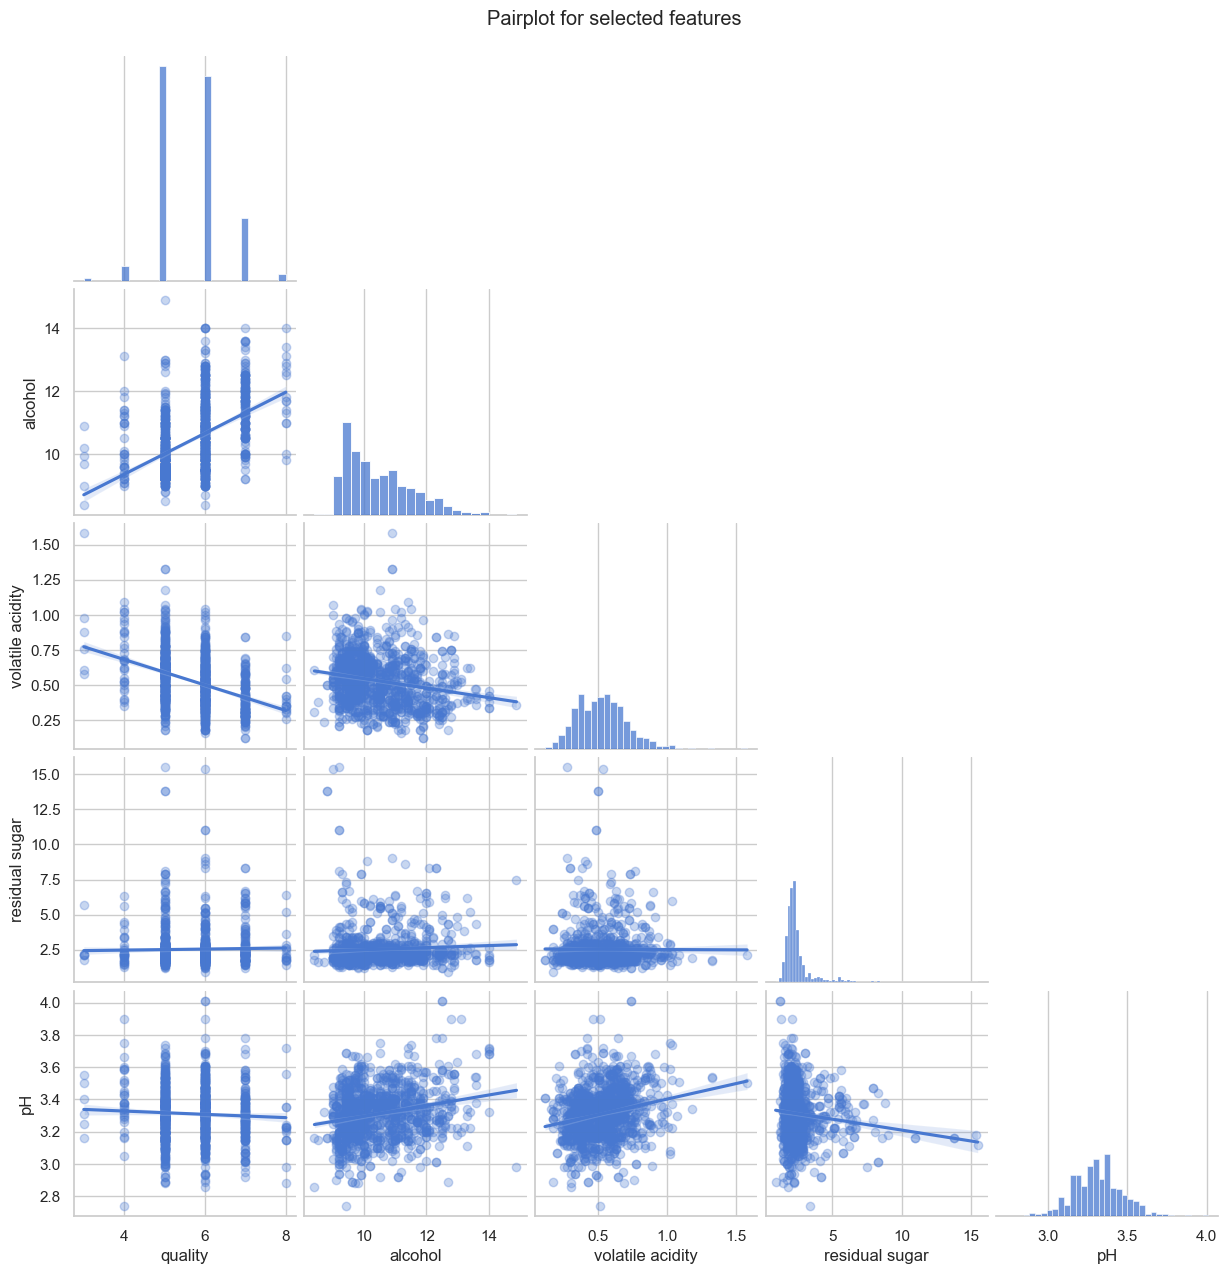

In [11]:
# Pairwise relationships for a selected subset of features
subset = ['quality','alcohol','volatile acidity','residual sugar','pH']
sns.pairplot(df[subset].dropna(), kind='reg', corner=True, plot_kws={'scatter_kws':{'alpha':0.3}})
plt.suptitle('Pairplot for selected features', y=1.02)
plt.show()

## Correlation Analysis
Compute correlation matrix and visualize which features correlate strongest with `quality`.

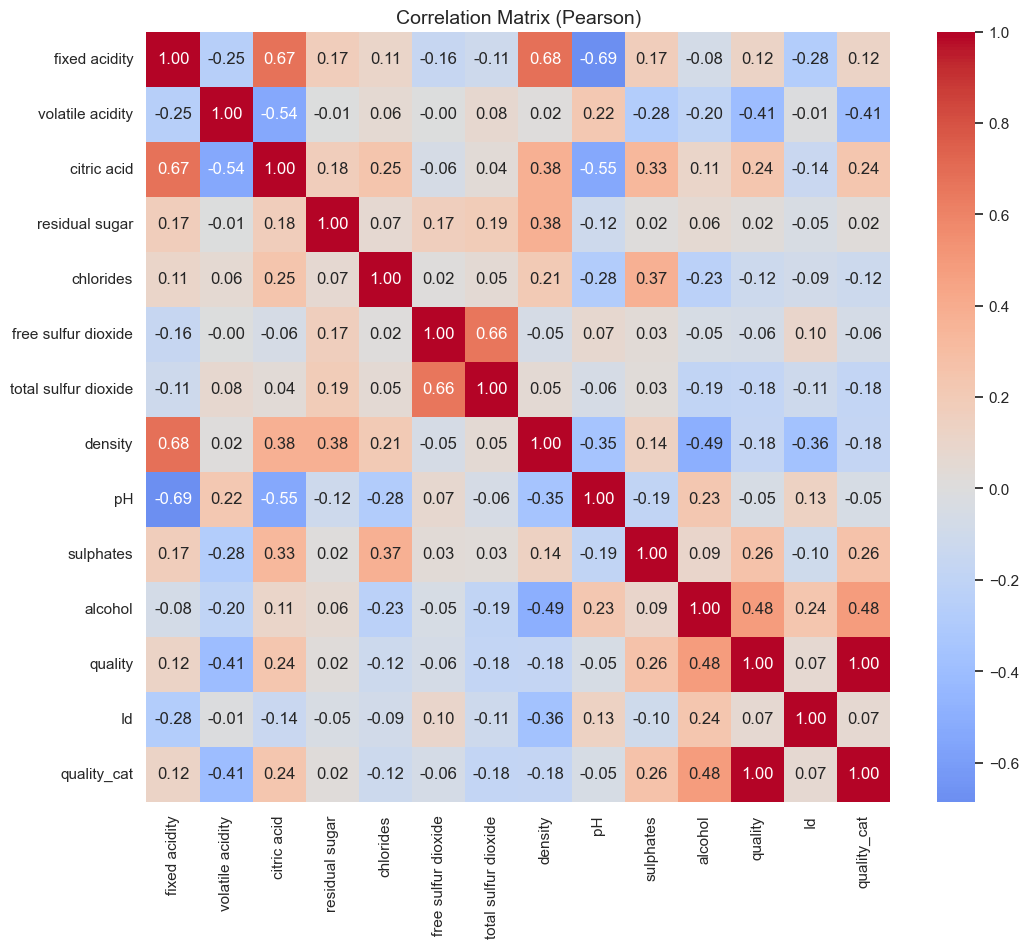

Top correlations with quality
 quality_cat             1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
Id                      0.069708
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


In [12]:
# Correlation matrix
corr = df.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Pearson)')
plt.show()
# Show top correlations with quality
quality_corr = corr['quality'].drop('quality').sort_values(ascending=False)
print('Top correlations with quality\n', quality_corr)

## Insights & Conclusion
Summarize the 3–5 key insights discovered during the EDA. Include recommended next steps.

**Key Insights**
- Alcohol shows a positive correlation with quality: higher-alcohol wines tend to receive higher quality scores.
- Volatile acidity tends to decrease as quality increases (negative correlation), suggesting lower volatile acidity is associated with better wines.
- Residual sugar has a weaker relationship with quality in this dataset; distributions are skewed and warrant transformation or segmentation.
- pH and other acidity measures show moderate relationships; multivariate modeling is needed to separate their combined effects.

**Next steps**: Build a simple predictive model (e.g., Random Forest) using the cleaned features, perform feature importance analysis, and consider creating a classification target (low/medium/high quality) for practical predictions.